# 02 — Análisis de calidad de datos

Evaluación sistemática de problemas de calidad en Bronze antes de construir Silver. Categorías analizadas:

1. Valores nulos
2. Duplicados (PKs y emails)
3. Integridad referencial (FKs huérfanas)
4. Reglas de negocio (scores, montos, estados)
5. Reconciliación financiera (facturas vs. ítems vs. pagos)
6. Consistencia de pesos en calificaciones

## Configuración

In [2]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def get_project_root():
    """Raíz del repo: local (notebooks/) o contenedor Jupyter (/home/jovyan/work)."""
    for path in [Path("/home/jovyan/work"), Path("..").resolve(), Path.cwd()]:
        if (path / "data" / "parquet" / "bronze").exists():
            return path
    raise FileNotFoundError(
        "No se encontró data/parquet/bronze. "
        "Ejecuta desde notebooks/ o levanta Docker Compose."
    )


PROJECT_ROOT = get_project_root()
BRONZE_PATH = PROJECT_ROOT / "data" / "parquet" / "bronze"

EMAIL_RE = re.compile(r"^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


def load_bronze(domain, table):
    return pd.read_parquet(BRONZE_PATH / domain / f"{table}.parquet")


students = load_bronze('university', 'students')
courses = load_bronze('university', 'courses')
semesters = load_bronze('university', 'semesters')
professors = load_bronze('university', 'professors')
enrollments = load_bronze('university', 'enrollments')
grades = load_bronze('university', 'grades')
customers = load_bronze('billing', 'customers')
products = load_bronze('billing', 'products')
subscriptions = load_bronze('billing', 'subscriptions')
invoices = load_bronze('billing', 'invoices')
invoice_items = load_bronze('billing', 'invoice_items')
payments = load_bronze('billing', 'payments')
accounts = load_bronze('crm', 'accounts')
contacts = load_bronze('crm', 'contacts')
leads = load_bronze('crm', 'leads')
opportunities = load_bronze('crm', 'opportunities')
opp_contacts = load_bronze('crm', 'opportunity_contacts')
activities = load_bronze('crm', 'activities')

PROJECT_ROOT: /home/jovyan/work


## 1. Valores nulos

In [3]:
null_rows = []
tables = {
    'university/students': students, 'university/enrollments': enrollments,
    'university/grades': grades, 'billing/customers': customers,
    'billing/invoices': invoices, 'crm/activities': activities,
}
for name, df in tables.items():
    for col in df.columns:
        if col.startswith('_'):
            continue
        n = df[col].isna().sum()
        if n > 0:
            null_rows.append({
                'tabla': name, 'columna': col,
                'nulos': n, 'pct': round(100 * n / len(df), 2),
            })

null_df = pd.DataFrame(null_rows).sort_values('pct', ascending=False)
null_df

,tabla,columna,nulos,pct
0,billing/customers,external_ref,5000,50.00
2,crm/activities,opportunity_id,9985,49.92
1,crm/activities,contact_id,5976,29.88


**Interpretación:**
- `customers.external_ref` nulo en 50% — esperado: mitad de clientes no son estudiantes.
- `activities.contact_id` y `opportunity_id` nulos — actividades pueden existir sin ambos vínculos.

## 2. Duplicados

In [6]:
pk_checks =[
    ('semesters', semesters, 'semester_id'),
    ('professors', professors, 'professor_id'),
    ('students', students, 'student_id'),
    ('courses', courses, 'course_id'),
    ('enrollments', enrollments, 'enrollment_id'),
    ('grades', grades, 'grade_id'),
    ('customers', customers, 'customer_id'),
    ('products', products, 'product_id'),
    ('subscriptions', subscriptions, 'subscription_id'),
    ('invoices', invoices, 'invoice_id'),
    ('invoice_items', invoice_items, 'invoice_item_id'),
    ('payments', payments, 'payment_id'),
    ('accounts', accounts, 'account_id'),
    ('contacts', contacts, 'contact_id'),
    ('leads', leads, 'lead_id'),
    ('opportunities', opportunities, 'opportunity_id'),
    ('activities', activities, 'activity_id')
]
for name, df, pk in pk_checks:
    dups = df[pk].duplicated().sum()
    print(f'{name}.{pk}: {dups} duplicados')

semesters.semester_id: 0 duplicados
professors.professor_id: 0 duplicados
students.student_id: 0 duplicados
courses.course_id: 0 duplicados
enrollments.enrollment_id: 0 duplicados
grades.grade_id: 0 duplicados
customers.customer_id: 0 duplicados
products.product_id: 0 duplicados
subscriptions.subscription_id: 0 duplicados
invoices.invoice_id: 0 duplicados
invoice_items.invoice_item_id: 0 duplicados
payments.payment_id: 0 duplicados
accounts.account_id: 0 duplicados
contacts.contact_id: 0 duplicados
leads.lead_id: 0 duplicados
opportunities.opportunity_id: 0 duplicados
activities.activity_id: 0 duplicados


In [17]:
email_tables = [
    ('professors', professors), ('students', students),
    ('customers', customers), ('contacts', contacts), ('leads', leads),
]
email_issues = []
for name, df in email_tables:
    empty = (df['email'].isna() | (df['email'].astype(str).str.strip() == '')).sum()
    invalid = sum(1 for e in df['email'].dropna() if not EMAIL_RE.match(str(e).strip()))
    dups = df['email'].duplicated().sum()
    email_issues.append({'tabla': name, 'vacios': empty, 'invalidos': invalid, 'duplicados': dups})

email_df = pd.DataFrame(email_issues)
email_df

,tabla,vacios,invalidos,duplicados
0,professors,0,0,0
1,students,0,0,0
2,customers,0,0,0
3,contacts,0,0,2
4,leads,0,0,0


In [6]:
dup_emails = contacts[contacts['email'].duplicated(keep=False)].sort_values('email')
print('Emails duplicados en contacts (distintos contact_id, distintas cuentas):')
dup_emails[['contact_id', 'email', 'account_id']]

Emails duplicados en contacts (distintos contact_id, distintas cuentas):


,contact_id,email,account_id
2466,CON-0002467,ignacio.tapia5946@mail.test,ACC-0002715
8391,CON-0008392,ignacio.tapia5946@mail.test,ACC-0004626
3103,CON-0003104,macarena.ortiz4996@lake.local,ACC-0003066
4934,CON-0004935,macarena.ortiz4996@lake.local,ACC-0001325


## 3. Integridad referencial

In [7]:
def count_orphans(child, child_col, parent, parent_col):
    mask = child[child_col].notna()
    orphans = child[mask & ~child[child_col].isin(parent[parent_col])]
    return len(orphans)


fk_checks = [
    ('enrollments', enrollments, 'student_id', students, 'student_id'),
    ('enrollments', enrollments, 'course_id', courses, 'course_id'),
    ('enrollments', enrollments, 'semester_id', semesters, 'semester_id'),
    ('grades', grades, 'enrollment_id', enrollments, 'enrollment_id'),
    ('courses', courses, 'professor_id', professors, 'professor_id'),
    ('invoices', invoices, 'customer_id', customers, 'customer_id'),
    ('invoice_items', invoice_items, 'invoice_id', invoices, 'invoice_id'),
    ('invoice_items', invoice_items, 'product_id', products, 'product_id'),
    ('payments', payments, 'invoice_id', invoices, 'invoice_id'),
    ('subscriptions', subscriptions, 'customer_id', customers, 'customer_id'),
    ('contacts', contacts, 'account_id', accounts, 'account_id'),
    ('opportunities', opportunities, 'account_id', accounts, 'account_id'),
    ('opp_contacts', opp_contacts, 'opportunity_id', opportunities, 'opportunity_id'),
    ('opp_contacts', opp_contacts, 'contact_id', contacts, 'contact_id'),
]

fk_rows = []
for label, child, ccol, parent, pcol in fk_checks:
    n = count_orphans(child, ccol, parent, pcol)
    fk_rows.append({'relacion': f'{label}.{ccol} -> {pcol}', 'huerfanos': n})

fk_df = pd.DataFrame(fk_rows)
fk_df

,relacion,huerfanos
0,enrollments.student_id -> student_id,0
1,enrollments.course_id -> course_id,0
2,enrollments.semester_id -> semester_id,0
3,grades.enrollment_id -> enrollment_id,0
4,courses.professor_id -> professor_id,0
5,invoices.customer_id -> customer_id,0
6,invoice_items.invoice_id -> invoice_id,0
7,invoice_items.product_id -> product_id,0
8,payments.invoice_id -> invoice_id,0
9,subscriptions.customer_id -> customer_id,0


In [8]:
ext_valid = customers.loc[customers['external_ref'].notna(), 'external_ref']
orph_ext = ext_valid[~ext_valid.isin(students['student_id'])].count()
print(f'external_ref huérfanos (no en students): {orph_ext}')
print(f'external_ref válidos: {len(ext_valid) - orph_ext}/{len(ext_valid)}')

external_ref huérfanos (no en students): 0
external_ref válidos: 5000/5000


## 4. Reglas de negocio

In [9]:
bad_scores = grades[(grades['score'] < 0) | (grades['score'] > 100)]
neg_invoices = invoices[invoices['total'] < 0]
neg_payments = payments[payments['amount'] < 0]
neg_items = invoice_items[invoice_items['line_total'] < 0]

business_checks = pd.DataFrame([
    {'regla': 'grades.score entre 0-100', 'violaciones': len(bad_scores),
     'detalle': f"min={grades['score'].min():.2f}, max={grades['score'].max():.2f}"},
    {'regla': 'invoices.total >= 0', 'violaciones': len(neg_invoices), 'detalle': ''},
    {'regla': 'payments.amount >= 0', 'violaciones': len(neg_payments), 'detalle': ''},
    {'regla': 'invoice_items.line_total >= 0', 'violaciones': len(neg_items), 'detalle': ''},
    {'regla': 'leads.score entre 0-100', 'violaciones': len(leads[(leads['score']<0)|(leads['score']>100)]),
     'detalle': f"min={leads['score'].min()}, max={leads['score'].max()}"},
])
business_checks

,regla,violaciones,detalle
0,grades.score entre 0-100,0,"min=24.53, max=100.00"
1,invoices.total >= 0,0,
2,payments.amount >= 0,0,
3,invoice_items.line_total >= 0,0,
4,leads.score entre 0-100,0,"min=0, max=100"


In [10]:
ii = invoice_items.copy()
ii['calc_total'] = ii['quantity'] * ii['unit_price']
ii_bad = ii[abs(ii['line_total'] - ii['calc_total']) > 0.01]
print(f'Ítems donde line_total != quantity * unit_price: {len(ii_bad)}')

Ítems donde line_total != quantity * unit_price: 0


## 5. Reconciliación financiera

In [11]:
items_sum = invoice_items.groupby('invoice_id')['line_total'].sum().reset_index(name='items_sum')
inv_recon = invoices.merge(items_sum, on='invoice_id', how='left')
inv_recon['items_sum'] = inv_recon['items_sum'].fillna(0)
inv_recon['diff'] = inv_recon['total'] - inv_recon['items_sum']

exact_match = (abs(inv_recon['diff']) <= 0.01).sum()
print(f'Facturas donde total == sum(items): {exact_match}/{len(inv_recon)}')
print('\nEstadísticas de diferencia (total - suma ítems):')
print(inv_recon['diff'].describe())

Facturas donde total == sum(items): 1/50000

Estadísticas de diferencia (total - suma ítems):
count    50000.000000
mean      -562.799123
std        602.397144
min      -5774.110000
25%       -855.952500
50%       -445.245000
75%       -137.865000
max       3772.150000
Name: diff, dtype: float64


In [12]:
pay_sum = payments.groupby('invoice_id')['amount'].sum().reset_index(name='paid_sum')
pay_recon = invoices.merge(pay_sum, on='invoice_id', how='left')
pay_recon['paid_sum'] = pay_recon['paid_sum'].fillna(0)

overpaid = pay_recon[pay_recon['paid_sum'] > pay_recon['total'] + 0.01]
underpaid_paid = pay_recon[(pay_recon['status'] == 'paid') & (pay_recon['paid_sum'] < pay_recon['total'] - 0.01)]

print(f'Facturas sobrepagadas: {len(overpaid)} ({100*len(overpaid)/len(pay_recon):.1f}%)')
print(f'Facturas status=paid pero pago < total: {len(underpaid_paid)} ({100*len(underpaid_paid)/len(pay_recon):.1f}%)')

Facturas sobrepagadas: 20482 (41.0%)
Facturas status=paid pero pago < total: 14477 (29.0%)


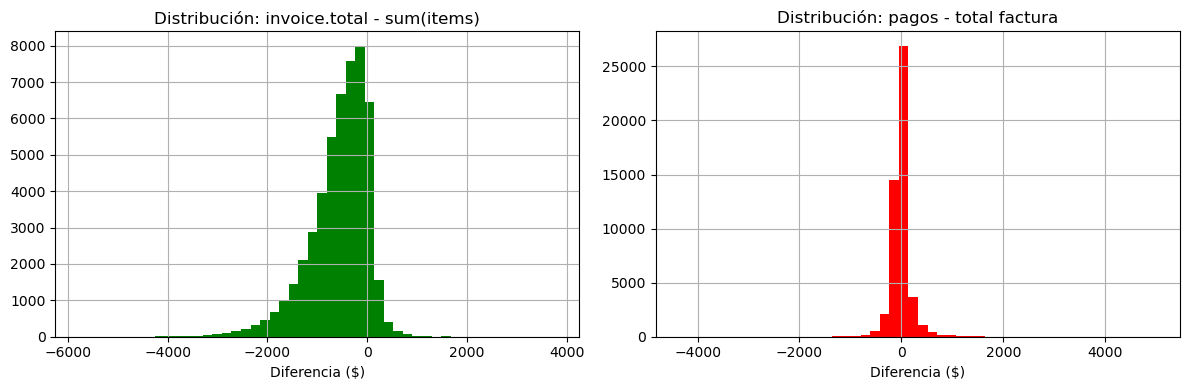

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
inv_recon['diff'].hist(bins=50, ax=axes[0], color='#008000')
axes[0].set_title('Distribución: invoice.total - sum(items)')
axes[0].set_xlabel('Diferencia ($)')

(pay_recon['paid_sum'] - pay_recon['total']).hist(bins=50, ax=axes[1], color='#FF0000')
axes[1].set_title('Distribución: pagos - total factura')
axes[1].set_xlabel('Diferencia ($)')
plt.tight_layout()
plt.show()

## 6. Pesos de calificaciones

In [20]:
weight_sum = grades.groupby('enrollment_id')['weight'].sum()
bad_weights = weight_sum[abs(weight_sum - 1.0) > 0.01]

print(f'Enrollments con suma de weights != 1: {len(bad_weights)} / {len(weight_sum)}')
print(f'({100*len(bad_weights)/len(weight_sum):.1f}%)')
print('\nEstadísticas de suma de weights por enrollment:')
print(weight_sum.describe())

Enrollments con suma de weights != 1: 22645 / 22786
(99.4%)

Estadísticas de suma de weights por enrollment:
count    22786.000000
mean         0.790914
std          0.466860
min          0.100000
25%          0.430000
50%          0.710000
75%          1.060000
max          3.310000
Name: weight, dtype: float64


## 7. Resumen de issues y tratamiento propuesto (Silver)

In [15]:
issues = pd.DataFrame([
    {'issue': 'customers.external_ref 50% nulo', 'severidad': 'Info', 'accion_silver': 'Mantener nulos; no es error'},
    {'issue': 'activities FKs nulas', 'severidad': 'Info', 'accion_silver': 'Permitir nulos; actividad puede ser independiente'},
    {'issue': '2 emails duplicados en contacts', 'severidad': 'Media', 'accion_silver': 'Marcar flag _email_duplicado; no eliminar'},
    {'issue': 'invoice.total != sum(items) en ~99.998%', 'severidad': 'Alta', 'accion_silver': 'Documentar; calcular campo _items_sum para análisis; no recalcular total'},
    {'issue': 'Facturas paid con pago < total', 'severidad': 'Alta', 'accion_silver': 'Marcar _payment_mismatch; revisar status en Gold'},
    {'issue': 'Facturas sobrepagadas', 'severidad': 'Media', 'accion_silver': 'Marcar _overpaid; posibles pagos parciales múltiples'},
    {'issue': 'Grade weights != 1 por enrollment', 'severidad': 'Media', 'accion_silver': 'Calcular _weight_sum; normalizar en Gold si aplica'},
    {'issue': 'Fechas como string en Bronze', 'severidad': 'Baja', 'accion_silver': 'Convertir a datetime64 con pd.to_datetime'},
    {'issue': 'PKs duplicadas', 'severidad': 'N/A', 'accion_silver': 'Sin acción — 0 duplicados detectados'},
    {'issue': 'FKs huérfanas (IDs inválidos)', 'severidad': 'N/A', 'accion_silver': 'Sin acción — 0 huérfanos detectados'},
])
issues

,issue,severidad,accion_silver
0,customers.external_ref 50% nulo,Info,Mantener nulos; no es error
1,activities FKs nulas,Info,Permitir nulos; actividad puede ser independiente
2,2 emails duplicados en contacts,Media,Marcar flag _email_duplicado; no eliminar
3,invoice.total != sum(items) en ~99.998%,Alta,Documentar; calcular campo _items_sum para aná...
4,Facturas paid con pago < total,Alta,Marcar _payment_mismatch; revisar status en Gold
5,Facturas sobrepagadas,Media,Marcar _overpaid; posibles pagos parciales múl...
6,Grade weights != 1 por enrollment,Media,Calcular _weight_sum; normalizar en Gold si ap...
7,Fechas como string en Bronze,Baja,Convertir a datetime64 con pd.to_datetime
8,PKs duplicadas,N/A,Sin acción — 0 duplicados detectados
9,FKs huérfanas (IDs inválidos),N/A,Sin acción — 0 huérfanos detectados


> **Nota:** Este resumen se replica y amplía en [`docs/decisiones.md`](../docs/decisiones.md) como registro formal de decisiones para la capa Silver y Gold.